## Week 12: 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from  sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv('data12_CreditCard_sample.csv')
df.sample(5)

,TOTAL_PURCHASES,PRC_CASH_ADVANCE,CREDIT_LIMIT,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
4970,1669.210000,0.000000,8500.0,521.675562,0.000000
7202,1875.089436,0.580313,1000.0,223.726642,0.083333
1428,1606.400000,0.692038,1000.0,879.124210,0.000000
5320,6067.596592,0.999998,6500.0,1542.906309,0.000000
1506,979.930000,0.000000,4350.0,470.064242,0.000000


In [5]:
df.describe()

,TOTAL_PURCHASES,PRC_CASH_ADVANCE,CREDIT_LIMIT,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,2019.619398,0.381541,4522.091030,864.304943,0.159304
std,2950.021139,0.442971,3659.240379,2372.566350,0.296271
min,0.010000,0.000000,50.000000,0.019163,0.000000
25%,379.667727,0.000000,1600.000000,169.163545,0.000000
50%,1095.557789,0.000000,3000.000000,312.452292,0.000000
75%,2556.502427,0.953255,6500.000000,825.496463,0.166667
max,49597.746886,1.000000,30000.000000,76406.207520,1.000000


In [6]:
x = StandardScaler().fit_transform(df)
x

array([[-0.65230747, -0.86137261, -0.96257545, -0.30550763, -0.53772694],
       [ 1.49951204,  1.39624097,  0.67720406,  0.08768873,  0.21238001],
       [-0.42254327, -0.86137261,  0.81385235, -0.09990611, -0.53772694],
       ...,
       [-0.63569645, -0.86137261, -0.96257545, -0.32957217,  0.30614422],
       [-0.67225465,  1.39562711, -1.09922375, -0.34081076,  0.30614422],
       [-0.27096947, -0.62634214, -0.90791614, -0.32709767, -0.53772694]])

In [7]:
km = KMeans(n_clusters = 6, n_init = 25, random_state = 101)
km.fit(x)

y_pred = km.predict(x)
y_pred

array([3, 5, 3, ..., 3, 1, 3], dtype=int32)

In [8]:
km.inertia_

14753.79905860133

In [9]:
km.cluster_centers_

array([[-0.14051765, -0.77541838,  0.08041747, -0.28780607,  2.18310998],
       [-0.15172568,  1.19707826, -0.42761659, -0.05963349, -0.42406797],
       [ 6.95680859,  0.14344264,  2.49720089,  0.95300822,  0.55121571],
       [-0.35253826, -0.78425977, -0.3011274 , -0.13620411, -0.34412283],
       [-0.02092203,  0.06837699, -0.08485419,  9.22950294, -0.52768089],
       [ 1.05626696,  0.47539683,  1.5139984 ,  0.32819665, -0.41193222]])

In [10]:
from collections import Counter
cnt = Counter(np.sort(y_pred))
cnt

Counter({3: 3436, 1: 2572, 0: 1270, 5: 1233, 2: 69, 4: 56})

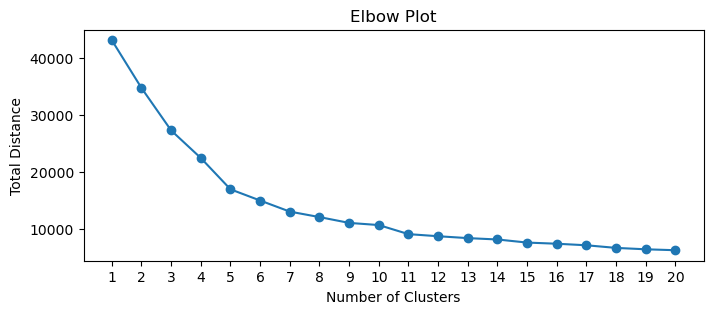

In [11]:
n_clusters = np.arange(1,21)
distances = np.zeros(n_clusters.shape[0])

for idx, nc in enumerate(n_clusters):
    model = KMeans(n_clusters = nc, random_state = 101)
    model.fit(x)
    distances[idx] = model.inertia_

fig, ax = plt.subplots(figsize = (8,3))
ax.scatter(n_clusters, distances)
ax.plot(n_clusters, distances)

ax.set(title = 'Elbow Plot' , xlabel = 'Number of Clusters' , ylabel = 'Total Distance')
ax.set_xticks(range(1,21,1))

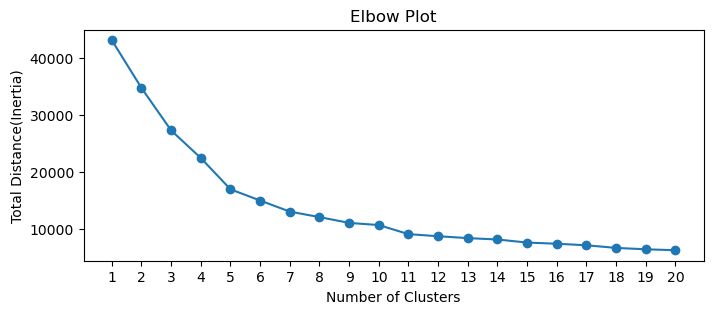

In [12]:
n_clusters = np.arange(1,21)
distances = np.zeros(n_clusters.shape[0])

for idx, nc in enumerate (n_clusters):
    model = KMeans(n_clusters=nc, random_state=101)
    model.fit(x)
    distances[idx] = model.inertia_
    
fig, ax = plt.subplots(figsize=(8,3))
ax.scatter(n_clusters, distances)
ax.plot(n_clusters, distances)

ax.set(title='Elbow Plot', xlabel='Number of Clusters', ylabel='Total Distance(Inertia)')
ax.set_xticks(range(1,21,1))

In [13]:
km = KMeans(n_clusters = 4, random_state = 101)
km.fit(x)
y_pred = km.predict(x)

df['cluster'] = y_pred
df.sample(5)

,TOTAL_PURCHASES,PRC_CASH_ADVANCE,CREDIT_LIMIT,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,cluster
771,1967.792148,0.999995,3000.0,316.461916,0.000000,2
4166,450.010000,0.000000,4000.0,181.630966,0.250000,0
7647,1711.370000,0.000000,3500.0,1106.494745,0.000000,0
4587,1147.240000,0.000000,4000.0,80.470536,0.181818,0
2184,37.701257,0.999735,1500.0,429.538368,0.000000,2


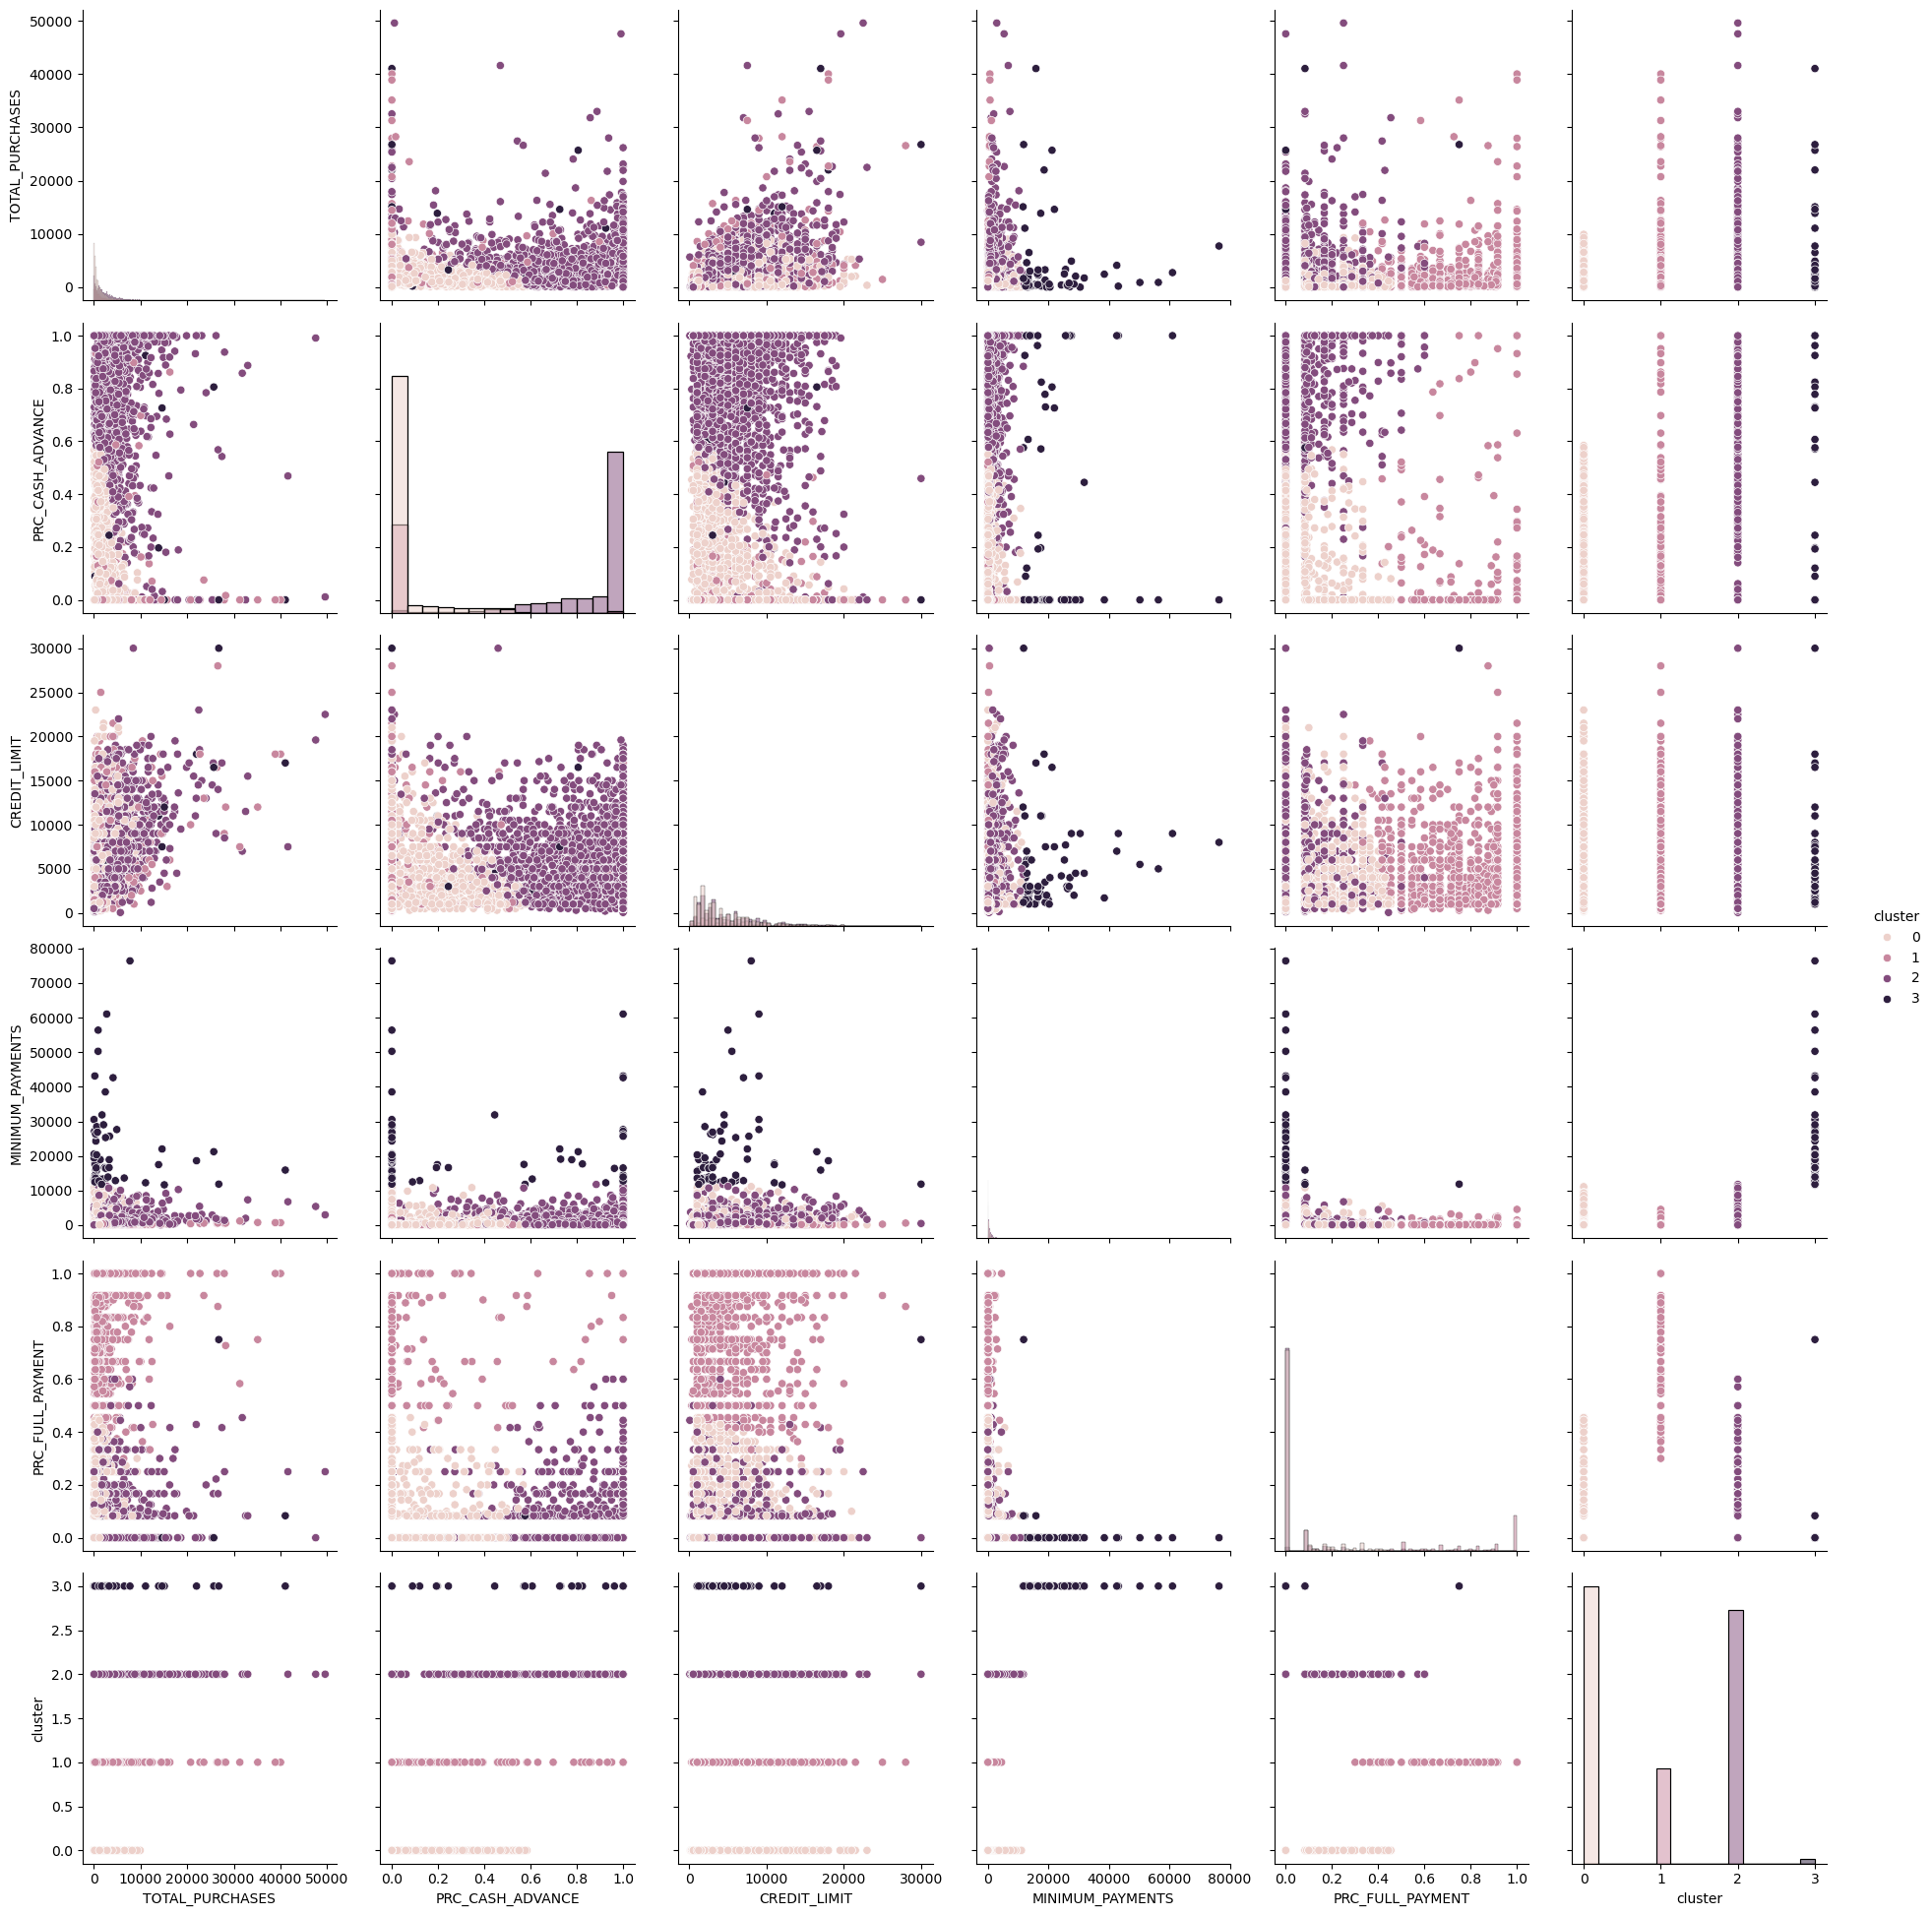

In [14]:
grid = sns.pairplot(df, vars = df.columns, hue = 'cluster', diag_kind = 'hist')
grid.fig.set_size_inches(20,20)

In [15]:
ss = silhouette_score(x, y_pred)
print(f'Silsilhouette_score) = {ss:.3f}')

Silsilhouette_score) = 0.374


In [22]:
db = DBSCAN(eps = 0.5, min_samples = 10)
db.fit(x)

# db.components_
print(f'Number of Core Points = {db.components_.shape[0]}')
print(f'Cluster lables = {np.unique(db.labels_)}')

Number of Core Points = 7472
Cluster lables = [-1  0  1  2  3]


In [24]:
cnt = Counter(np.sort(db.labels_))
cnt

Counter({0: 7810, -1: 781, 3: 20, 1: 16, 2: 9})